# 03. Qiskit UQK Overlap Hyperparameter Experiment

This notebook reuses the Qiskit UQK overlap machinery from notebook 02 to study how overlap-matrix error changes with qDRIFT segment count `Nd`, stochastic instances per correlation `Nw`/`sipc`, and MFE shots `Nmfe`.

The reference matrix is named `S_reference` throughout the notebook. By default it is generated once with `exact_trotter` and cached under `notebooks/<molecule>/experiments/uqk_overlap_hyperparameters/S_reference/`, but the setup cell exposes override paths so another reference can be swapped in cleanly.

## Cell 0: Experiment Setup And S_reference

Set the molecule, backend, shared Krylov dimension, random seeds, and optional `S_reference` override paths here. The backend defaults to `local_noiseless_statevector`, but all backend/noise options are grouped so the same sweep can be rerun against a noisy simulator later.

In [1]:
from pathlib import Path
import sys

CANDIDATE_ROOTS = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(path for path in CANDIDATE_ROOTS if (path / "notebooks" / "workflow_helpers").exists())
NOTEBOOKS_ROOT = REPO_ROOT / "notebooks"
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

from workflow_helpers.qiskit_uqk_helpers import (
    build_grouped_evolution_circuits,
    load_workflow_manifest,
)
from workflow_helpers.uqk_hyperparameter_helpers import (
    derive_shot_pairs,
    ensure_s_reference,
    generate_plot1_exact_stochastic_data,
    generate_plot2_stochastic_shot_budget_data,
    generate_plot3_standard_nmfe_data,
    plot1_exact_stochastic,
    plot2_stochastic_shot_budget,
    plot3_standard_nmfe,
    prepare_experiment_context,
)

# --- User-facing workflow options ---
MOLECULE_NAME = "diatomic_h2_sto_3g"
EXPERIMENT_NAME = "uqk_overlap_hyperparameters"
BACKEND_MODE = "local_noiseless_statevector"
KRYLOV_DIMENSION = 4
MAX_CORRELATION_POWER = KRYLOV_DIMENSION
RANDOM_SEED = 230623
STOCHASTIC_WEIGHT_CONVENTION = "group_pauli_l1_norm"
REUSE_EXISTING = True
QUIET_RUNS = True
RUN_JOBS_DEFAULT = True

# Optional grouped-circuit rebuild. Defaults to reusing the manifest produced by notebook 02.
REBUILD_GROUPED_CIRCUITS = False
DT = 0.1
EVOLUTION_METHOD = "pauli_evolution_gate"
TARGET_MODE = "generic_simulator"
GENERIC_BASIS_GATES = ["rz", "sx", "x", "cx"]
TRANSPILER_OPTIMIZATION_LEVEL = 3
TROTTER_SEQUENCE_ORDER = 1

# User-facing S_reference override knobs. Leave as None to generate/reuse exact_trotter.
S_REFERENCE_NPZ_OVERRIDE = None
S_REFERENCE_METADATA_JSON_OVERRIDE = None

# Backend/noise knobs are passed to every finite-shot run. They are inert for exact MFE modes.
BACKEND_OPTIONS = {
    "noisy_simulation_method": "density_matrix",
    "noisy_transpile_optimization_level": 1,
    "simple_noise_one_qubit_depolarizing_probability": 1.0e-3,
    "simple_noise_two_qubit_depolarizing_probability": 1.0e-2,
    "simple_noise_readout_error_probability": 2.0e-2,
    "ibm_model_source": "fake_backend",
    "ibm_model_fake_backend_class": "FakeBrisbane",
    "ibm_model_runtime_backend_name": "ibm_brisbane",
    "ibm_model_compress_to_active_space": True,
}

if REBUILD_GROUPED_CIRCUITS:
    manifest_path, manifest = load_workflow_manifest(NOTEBOOKS_ROOT, MOLECULE_NAME)
    manifest, circuit_metadata = build_grouped_evolution_circuits(
        manifest_path=manifest_path,
        manifest=manifest,
        dt=DT,
        evolution_method=EVOLUTION_METHOD,
        target_mode=TARGET_MODE,
        generic_basis_gates=GENERIC_BASIS_GATES,
        transpiler_optimization_level=TRANSPILER_OPTIMIZATION_LEVEL,
        trotter_sequence_order=TROTTER_SEQUENCE_ORDER,
        verbose=True,
    )

context = prepare_experiment_context(
    NOTEBOOKS_ROOT,
    molecule_name=MOLECULE_NAME,
    experiment_name=EXPERIMENT_NAME,
)

s_reference_result = ensure_s_reference(
    context,
    krylov_dimension=KRYLOV_DIMENSION,
    backend_mode=BACKEND_MODE,
    random_seed=RANDOM_SEED,
    stochastic_weight_convention=STOCHASTIC_WEIGHT_CONVENTION,
    s_reference_npz_override=S_REFERENCE_NPZ_OVERRIDE,
    s_reference_metadata_override=S_REFERENCE_METADATA_JSON_OVERRIDE,
    reuse_existing=REUSE_EXISTING,
    quiet=QUIET_RUNS,
    **BACKEND_OPTIONS,
)
S_reference = s_reference_result["S"]

print("Experiment root:", context.experiment_root)
print("S_reference NPZ:", s_reference_result["npz_path"])
print("S_reference metadata:", s_reference_result["metadata_path"])
print("S_reference info JSON:", context.data_dir / "S_reference_info.json")

Experiment root: /Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters
S_reference NPZ: /Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/S_reference/diatomic_h2_sto_3g_S_reference_exact_trotter_backend_local_noiseless_statevector_M_4_dt_0p1_uqk_overlap_matrix.npz
S_reference metadata: /Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/S_reference/diatomic_h2_sto_3g_S_reference_exact_trotter_backend_local_noiseless_statevector_M_4_dt_0p1_uqk_overlap_matrix_metadata.json
S_reference info JSON: /Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/S_reference_info.json


## Cell 1a: Generate Plot 1 Data

Plot 1 measures `||S_reference - S_exact_stochastic||_F / ||S_reference||_F` over `Nd = [1, 2, 4, 8, 16, 32, 64]` and `Nw = sipc = [5, 10, 20, 40, 80, 160]` using exact MFE probabilities for each sampled qDRIFT circuit. Set `PLOT1_RUN_JOBS = False` to load the existing saved records and paths without launching UQK jobs.

In [2]:
PLOT1_ND_VALUES = [1, 2, 4, 8, 16, 32, 64]
PLOT1_NW_VALUES = [5, 10, 20, 40, 80, 160]
PLOT1_RANDOM_SEED = RANDOM_SEED + 10_000
PLOT1_RUN_JOBS = False

plot1_records, plot1_data_paths = generate_plot1_exact_stochastic_data(
    context,
    S_reference,
    nd_values=PLOT1_ND_VALUES,
    sipc_values=PLOT1_NW_VALUES,
    krylov_dimension=KRYLOV_DIMENSION,
    backend_mode=BACKEND_MODE,
    random_seed=PLOT1_RANDOM_SEED,
    stochastic_weight_convention=STOCHASTIC_WEIGHT_CONVENTION,
    reuse_existing=REUSE_EXISTING,
    RUN_JOBS=PLOT1_RUN_JOBS,
    quiet=QUIET_RUNS,
    **BACKEND_OPTIONS,
)
plot1_data_paths


Plot 1 Data: exact_stochastic qDRIFT convergence
RUN_JOBS:                                False
Loaded records:                          42
Data JSON:                               /Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot1_exact_stochastic_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.json


{'csv': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot1_exact_stochastic_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.csv'),
 'json': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot1_exact_stochastic_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.json')}

## Cell 1b: Plot 1 Figure And Summary Table

This cell writes the Plot 1 PNG/PDF files and a compact best-by-`Nw` summary table.

{'plots': {'png': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/plots/plot1_exact_stochastic_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.png'),
  'pdf': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/plots/plot1_exact_stochastic_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.pdf')},
 'table': {'csv': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/tables/plot1_exact_stochastic_best_by_Nw_backend_local_noiseless_statevector_M_4_dt_0p1.csv'),
  'markdown': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/tables/plot1_exact_stochastic_best_by_Nw_backend_local_noiseless_statevector_M_4_dt_0p1.md'),
  'records': [{'Nd': 64,
    'Nmfe': None,
    'Nw': 5,
    'absolute_frobenius_error': 0.06053256666067553,


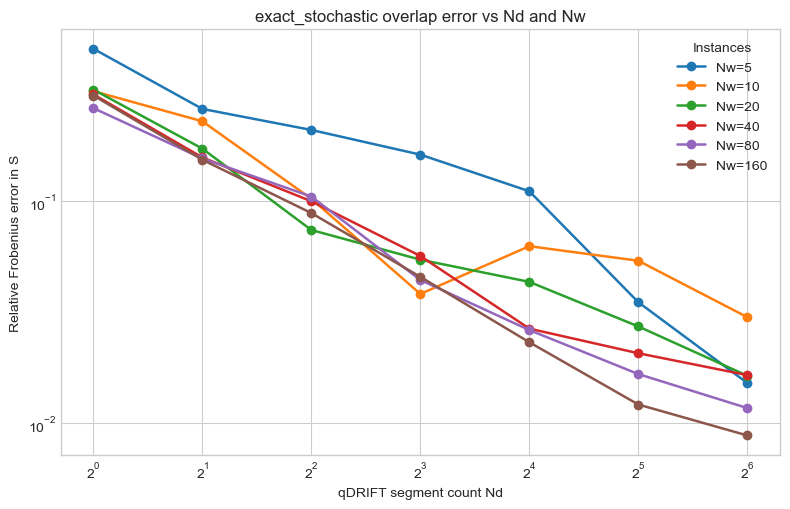

In [3]:
plot1_outputs = plot1_exact_stochastic(plot1_records, context)
plot1_outputs

## Cell 2a: Generate Plot 2 Data

Plot 2 measures finite-shot stochastic overlap error versus `Nd` under fixed per-correlation shot budgets `Nk = Nmfe * Nw`. The configured ratios are `R = Nmfe / Nw`. Set `PLOT2_RUN_JOBS = False` to load the existing saved records and paths without launching UQK jobs.

In [4]:
PLOT2_ND_VALUES = [1, 2, 4, 8, 16, 32, 64]
PLOT2_TOTAL_SHOTS = [10_000, 100_000]
PLOT2_RATIOS_BY_NK = {
    10_000: [100, 4, 1],
    100_000: [1000, 40, 10],
}
PLOT2_RANDOM_SEED = RANDOM_SEED + 20_000
PLOT2_RUN_JOBS = RUN_JOBS_DEFAULT

PLOT2_SHOT_PAIRS = {
    nk: derive_shot_pairs(nk, PLOT2_RATIOS_BY_NK[nk])
    for nk in PLOT2_TOTAL_SHOTS
}
for nk, pairs in PLOT2_SHOT_PAIRS.items():
    readable_pairs = [
        (pair["shots_per_mfe_experiment"], pair["stochastic_instances_per_correlation"], pair["ratio_nmfe_over_nw"])
        for pair in pairs
    ]
    print(f"Nk={nk:,} gives (Nmfe, Nw, R) = {readable_pairs}")

plot2_records, plot2_data_paths = generate_plot2_stochastic_shot_budget_data(
    context,
    S_reference,
    nd_values=PLOT2_ND_VALUES,
    total_shots_values=PLOT2_TOTAL_SHOTS,
    ratios_by_total_shots=PLOT2_RATIOS_BY_NK,
    krylov_dimension=KRYLOV_DIMENSION,
    backend_mode=BACKEND_MODE,
    random_seed=PLOT2_RANDOM_SEED,
    stochastic_weight_convention=STOCHASTIC_WEIGHT_CONVENTION,
    reuse_existing=REUSE_EXISTING,
    RUN_JOBS=PLOT2_RUN_JOBS,
    quiet=QUIET_RUNS,
    **BACKEND_OPTIONS,
)
plot2_data_paths

Nk=10,000 gives (Nmfe, Nw, R) = [(1000, 10, 100.0), (200, 50, 4.0), (100, 100, 1.0)]
Nk=100,000 gives (Nmfe, Nw, R) = [(10000, 10, 1000.0), (2000, 50, 40.0), (1000, 100, 10.0)]

Plot 2 Data: finite-shot stochastic qDRIFT
Nk=10000, R=100.0, Nd=1                  rel_fro=2.274215e-01
Nk=10000, R=100.0, Nd=2                  rel_fro=1.509092e-01
Nk=10000, R=100.0, Nd=4                  rel_fro=9.933799e-02
Nk=10000, R=100.0, Nd=8                  rel_fro=8.201446e-02
Nk=10000, R=100.0, Nd=16                 rel_fro=5.024574e-02
Nk=10000, R=100.0, Nd=32                 rel_fro=4.205531e-02
Nk=10000, R=100.0, Nd=64                 rel_fro=4.238143e-02
Nk=10000, R=4.0, Nd=1                    rel_fro=3.189142e-01
Nk=10000, R=4.0, Nd=2                    rel_fro=1.554796e-01
Nk=10000, R=4.0, Nd=4                    rel_fro=7.372451e-02
Nk=10000, R=4.0, Nd=8                    rel_fro=9.732247e-02
Nk=10000, R=4.0, Nd=16                   rel_fro=3.886871e-02
Nk=10000, R=4.0, Nd=32             

{'csv': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot2_stochastic_shot_budget_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.csv'),
 'json': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot2_stochastic_shot_budget_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.json')}

## Cell 2b: Plot 2 Figure And Summary Table

This cell writes the Plot 2 PNG/PDF files and a compact best-by-`Nk` and `R` summary table.

{'plots': {'png': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/plots/plot2_stochastic_shot_budget_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.png'),
  'pdf': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/plots/plot2_stochastic_shot_budget_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.pdf')},
 'table': {'csv': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/tables/plot2_stochastic_best_by_Nk_and_R_backend_local_noiseless_statevector_M_4_dt_0p1.csv'),
  'markdown': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/tables/plot2_stochastic_best_by_Nk_and_R_backend_local_noiseless_statevector_M_4_dt_0p1.md'),
  'records': [{'plot': 'plot2',
    'uqk_mode': 'stochastic',
    'backend_mode': 'local_noiseles

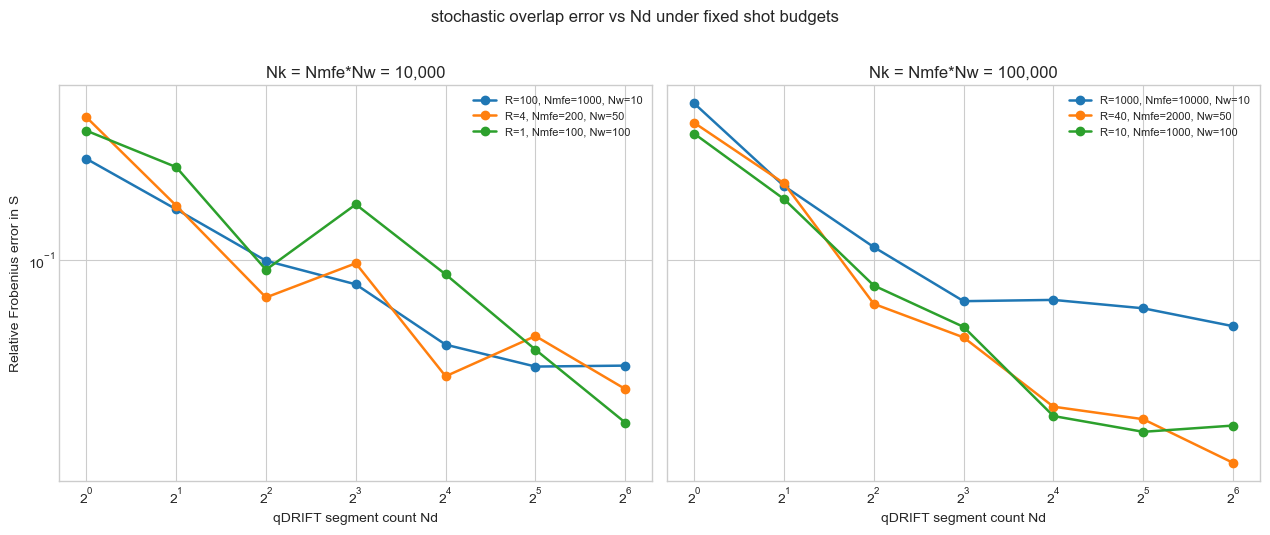

In [5]:
plot2_outputs = plot2_stochastic_shot_budget(plot2_records, context)
plot2_outputs

## Cell 3a: Generate Plot 3 Data

Plot 3 measures finite-shot standard Trotter overlap error over `Nmfe = [1_000, 10_000, 100_000, 1_000_000]`. Set `PLOT3_RUN_JOBS = False` to load the existing saved records and paths without launching UQK jobs.

In [6]:
PLOT3_NMFE_VALUES = [1_000, 10_000, 100_000, 1_000_000]
PLOT3_RANDOM_SEED = RANDOM_SEED + 30_000
PLOT3_RUN_JOBS = RUN_JOBS_DEFAULT

plot3_records, plot3_data_paths = generate_plot3_standard_nmfe_data(
    context,
    S_reference,
    nmfe_values=PLOT3_NMFE_VALUES,
    krylov_dimension=KRYLOV_DIMENSION,
    backend_mode=BACKEND_MODE,
    random_seed=PLOT3_RANDOM_SEED,
    stochastic_weight_convention=STOCHASTIC_WEIGHT_CONVENTION,
    reuse_existing=REUSE_EXISTING,
    RUN_JOBS=PLOT3_RUN_JOBS,
    quiet=QUIET_RUNS,
    **BACKEND_OPTIONS,
)
plot3_data_paths


Plot 3 Data: finite-shot standard Trotter
Nmfe=1000                                rel_fro=1.266235e-02
Nmfe=10000                               rel_fro=5.889224e-03
Nmfe=100000                              rel_fro=3.096219e-03
Nmfe=1000000                             rel_fro=7.001818e-04


{'csv': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot3_standard_nmfe_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.csv'),
 'json': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/data/plot3_standard_nmfe_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.json')}

## Cell 3b: Plot 3 Figure And Summary Table

This cell writes the Plot 3 PNG/PDF files and a compact summary table.

{'plots': {'png': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/plots/plot3_standard_nmfe_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.png'),
  'pdf': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/plots/plot3_standard_nmfe_overlap_error_backend_local_noiseless_statevector_M_4_dt_0p1.pdf')},
 'table': {'csv': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/tables/plot3_standard_nmfe_summary_backend_local_noiseless_statevector_M_4_dt_0p1.csv'),
  'markdown': PosixPath('/Users/nstair/Src/qforte-qiskit/notebooks/diatomic_h2_sto_3g/experiments/uqk_overlap_hyperparameters/tables/plot3_standard_nmfe_summary_backend_local_noiseless_statevector_M_4_dt_0p1.md'),
  'records': [{'plot': 'plot3',
    'uqk_mode': 'standard',
    'backend_mode': 'local_noiseless_statevector',
    'krylov_dime

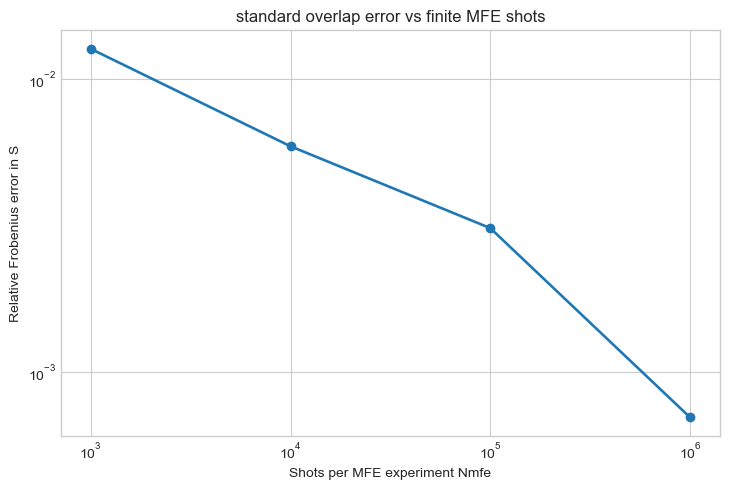

In [7]:
plot3_outputs = plot3_standard_nmfe(plot3_records, context)
plot3_outputs